# How are in demand-skills trending for Data Analysts?

## Methodology

1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monnthly skill demand

In [27]:
# Importing Libraries
import ast
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [28]:
df_DA_NL = df[(df["job_country"] == "Netherlands") & (df["job_title_short"] == "Data Analyst")].copy()

In [29]:
df_DA_NL["job_posted_month_no"] = df_DA_NL["job_posted_date"].dt.month

In [30]:
df_DA_NL_explode = df_DA_NL.explode("job_skills")

In [31]:
df_DA_NL_pivot = df_DA_NL_explode.pivot_table(index="job_posted_month_no", columns="job_skills", aggfunc="size", fill_value=0)

In [32]:
df_DA_NL_pivot.loc["Total"] = df_DA_NL_pivot.sum()

df_DA_NL_pivot

job_skills,airflow,airtable,alteryx,angular,ansible,asana,asp.net,asp.net core,assembly,atlassian,...,vb.net,vba,visio,visual basic,watson,webex,windows,word,wrike,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,14,0,14,0,0,0,0,0,0,0,...,0,15,3,0,0,1,0,30,0,2
2,14,0,7,0,0,0,0,0,0,0,...,0,2,0,0,0,0,1,14,0,1
3,13,0,9,0,0,0,0,0,0,1,...,0,17,0,0,1,0,3,28,0,0
4,10,0,6,0,0,0,0,0,0,0,...,0,13,0,0,1,3,1,33,0,1
5,8,0,4,0,0,0,0,0,0,0,...,0,4,1,0,0,4,2,23,0,1
6,6,0,6,1,0,0,0,0,0,0,...,0,5,5,0,0,4,1,33,2,1
7,4,0,1,0,0,0,0,0,0,0,...,0,8,1,0,0,2,0,25,0,3
8,4,0,0,0,0,0,0,0,0,0,...,0,10,0,0,0,3,0,30,0,1
9,1,0,4,1,0,0,0,0,0,0,...,1,12,1,0,0,0,1,40,0,0


In [33]:
df_DA_NL_pivot = df_DA_NL_pivot[df_DA_NL_pivot.loc["Total"].sort_values(ascending=False).index]

In [34]:
df_DA_NL_pivot = df_DA_NL_pivot.drop("Total")

<Axes: xlabel='job_posted_month_no'>

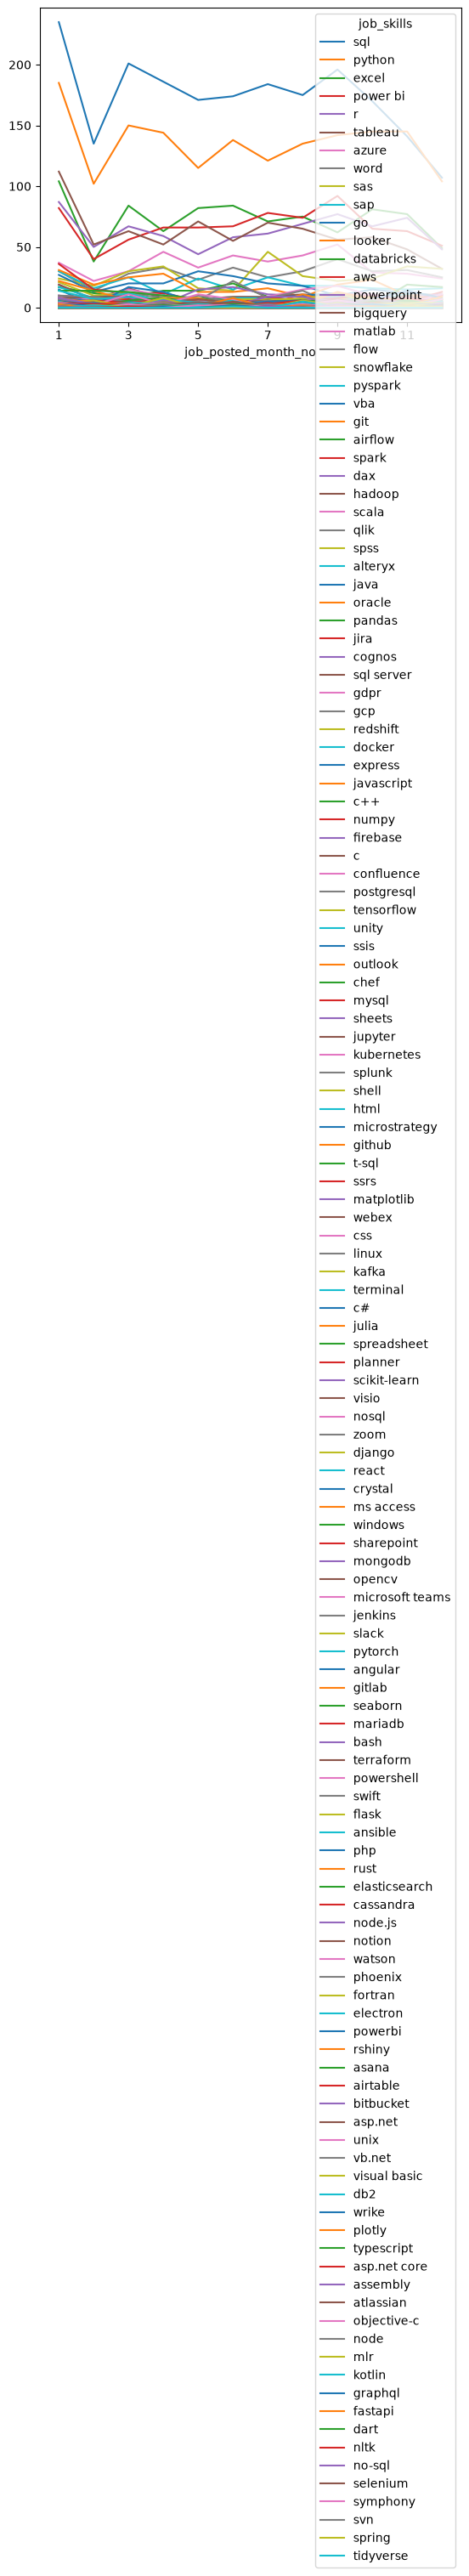

In [35]:
df_DA_NL_pivot.plot(kind="line")

In [36]:
DA_total = df_DA_NL.groupby("job_posted_month_no").size()

In [37]:
df_DA_NL_percent = df_DA_NL_pivot.div(DA_total/100, axis=0)

In [38]:
df_DA_NL_percent = df_DA_NL_percent.reset_index()

In [39]:
df_DA_NL_percent["job_posted_month"] = df_DA_NL_percent["job_posted_month_no"].apply(lambda x: pd.to_datetime(x, format="%m").strftime("%b"))
df_DA_NL_percent = df_DA_NL_percent.set_index("job_posted_month")
df_DA_NL_percent = df_DA_NL_percent.drop(columns="job_posted_month_no")

df_DA_NL_percent

job_skills,sql,python,excel,power bi,r,tableau,azure,word,sas,sap,...,graphql,fastapi,dart,nltk,no-sql,selenium,symphony,svn,spring,tidyverse
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,52.106430,41.019956,23.059867,18.181818,19.290466,24.833703,8.203991,6.651885,5.321508,6.651885,...,0.221729,0.000000,0.000000,0.000000,0.000000,0.221729,0.221729,0.221729,0.000000,0.000000
Feb,58.189655,43.965517,16.379310,17.241379,21.551724,22.413793,9.482759,6.034483,7.758621,6.896552,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,58.092486,43.352601,24.277457,16.184971,19.364162,18.208092,8.670520,8.092486,8.670520,7.225434,...,0.000000,0.000000,0.000000,0.289017,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,53.602305,41.498559,18.155620,19.020173,17.002882,14.985591,13.256484,9.510086,9.798271,3.170029,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,56.250000,37.828947,26.973684,21.710526,14.473684,23.355263,10.855263,7.565789,5.263158,7.894737,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,48.467967,38.440111,23.398329,18.662953,16.155989,15.320334,11.977716,9.192201,3.899721,4.178273,...,0.000000,0.000000,0.278552,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.278552
Jul,54.277286,35.693215,20.943953,23.008850,17.994100,20.648968,11.209440,7.374631,13.569322,7.374631,...,0.000000,0.000000,0.000000,0.000000,0.294985,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,48.882682,37.709497,20.949721,20.670391,19.273743,18.156425,12.011173,8.379888,7.262570,5.027933,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,56.000000,40.571429,17.714286,26.285714,22.000000,16.000000,14.857143,11.428571,6.285714,5.142857,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [41]:
df_plot = df_DA_NL_percent.iloc[:, :5]

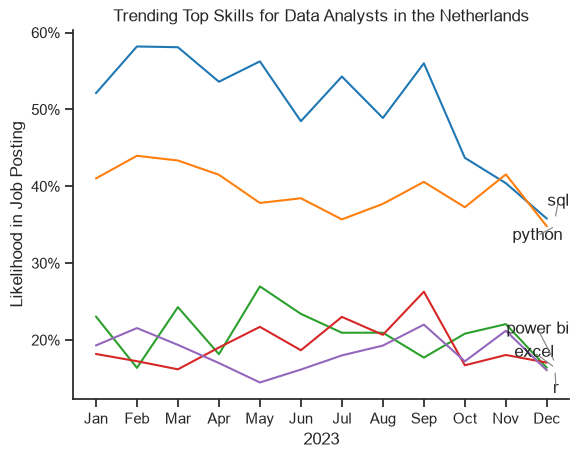

In [60]:

sns.lineplot(data=df_plot, dashes=False, palette="tab10")
sns.set_theme(style="ticks")
sns.despine()
plt.title("Trending Top Skills for Data Analysts in the Netherlands")
plt.ylabel("Likelihood in Job Posting")
plt.xlabel("2023")
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

from adjustText import adjust_text
# Labels maken
texts = []
for i in range(5):
    texts.append(
        plt.text(
            11.2,                       # positie rechts van de grafiek
            df_plot.iloc[-1, i],        # laatste waarde van de lijn
            df_plot.columns[i]
        )
    )

# Labels automatisch verschuiven + lijntjes tekenen
adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        lw=0.8
    ),
    expand_points=(2, 2),
    expand_text=(2, 2),
    force_text=0.8,
    force_points=0.8
)

plt.show()
